In [5]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install matplotlib opencv-python pycocotools

Looking in indexes: https://download.pytorch.org/whl/cu118


In [6]:
# Install SAM
!git clone https://github.com/facebookresearch/segment-anything.git
!pip install -e ./segment-anything

fatal: destination path 'segment-anything' already exists and is not an empty directory.
Obtaining file:///content/Cell-Type-Classifier/segment-anything
  Preparing metadata (setup.py) ... done
  Attempting uninstall: segment_anything
    Found existing installation: segment_anything 1.0
    Uninstalling segment_anything-1.0:
      Successfully uninstalled segment_anything-1.0
  Running setup.py develop for segment_anything


In [7]:
!pip show segment-anything

Name: segment_anything
Version: 1.0
Summary: 
Home-page: 
Author: 
Author-email: 
License: 
Location: /content/Cell-Type-Classifier/segment-anything
Editable project location: /content/Cell-Type-Classifier/segment-anything
Requires: 
Required-by: 


In [8]:
# Download Checkpoint
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-04-26 23:44:20--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.35.238.103, 13.35.238.84, 13.35.238.113, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.35.238.103|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘sam_vit_h_4b8939.pth.2’

sam_vit_h_4b8939.pt 100%[===================>]   2.39G   121MB/s    in 14s     

2026-04-26 23:44:34 (171 MB/s) - ‘sam_vit_h_4b8939.pth.2’ saved [2564550879/2564550879]



In [9]:
# Verify Installation. It will require that you restart the session
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
print("SAM is ready")

SAM is ready


In [10]:
# Getting a generic image from the SAM repository
!wget https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/dog.jpg

--2026-04-26 23:44:34--  https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/dog.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 99846 (98K) [image/jpeg]
Saving to: ‘dog.jpg.2’

dog.jpg.2           100%[===================>]  97.51K  --.-KB/s    in 0.001s  

2026-04-26 23:44:34 (71.8 MB/s) - ‘dog.jpg.2’ saved [99846/99846]



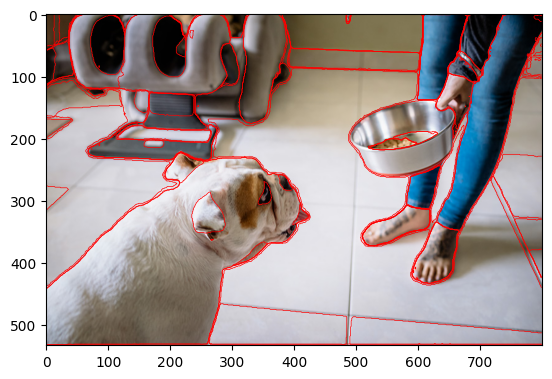

In [11]:
# Testing SAM on a generic image
import torch
import cv2
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

sam = sam_model_registry["vit_h"](checkpoint="sam_vit_h_4b8939.pth")
sam.to("cuda")

mask_generator = SamAutomaticMaskGenerator(sam)

image = cv2.imread("dog.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

masks = mask_generator.generate(image)

plt.imshow(image)
for m in masks:
    plt.contour(m['segmentation'], colors='r', linewidths=0.5)
plt.show()

In [12]:
!git clone https://github.com/JorgeMato43/Cell-Type-Classifier.git
%cd Cell-Type-Classifier
import sys
sys.path.append('/content/Cell-Type-Classifier')

Cloning into 'Cell-Type-Classifier'...
remote: Enumerating objects: 162, done.
remote: Counting objects: 100% (162/162), done.
remote: Compressing objects: 100% (154/154), done.
remote: Total 162 (delta 87), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (162/162), 58.00 KiB | 2.23 MiB/s, done.
Resolving deltas: 100% (87/87), done.
/content/Cell-Type-Classifier/Cell-Type-Classifier


In [13]:
# Makes root directories.
# Modify ROOT to your desired location and
# the script will download and unzip livecell
# images and annotations there.
# If working in Jupiter Notebooks, paste this sript in your desired notebook
# to download the livecell data

from src.data_loader import *

ROOT = "/content/livecell"
ANN_DIR, IMG_DIR = make_dir(ROOT)

download_livecell_data(ROOT, ANN_DIR)
unzip_images(ROOT, IMG_DIR=IMG_DIR)



/content/livecell
Already exists: /content/livecell/images.zip
Already exists: /content/livecell/annotations/livecell_coco_train.json
Already exists: /content/livecell/annotations/livecell_coco_val.json
Already exists: /content/livecell/annotations/livecell_coco_test.json
Done.
Unzipped to: /content/livecell/images


In [14]:
# Load COCO annotations
from pycocotools.coco import COCO

coco = COCO("/content/livecell/annotations/livecell_coco_train.json")

img_ids = coco.getImgIds()
img_info = coco.loadImgs(img_ids[0])[0]

print(img_info)

loading annotations into memory...
Done (t=15.87s)
creating index...
index created!
{'id': 1, 'width': 704, 'height': 520, 'file_name': 'BT474_Phase_A3_2_00d04h00m_3.tif', 'original_filename': 'BT474_Phase_A3_2_00d04h00m_3.png', 'url': 'https://darwin.v7labs.com/api/images/870028/original'}


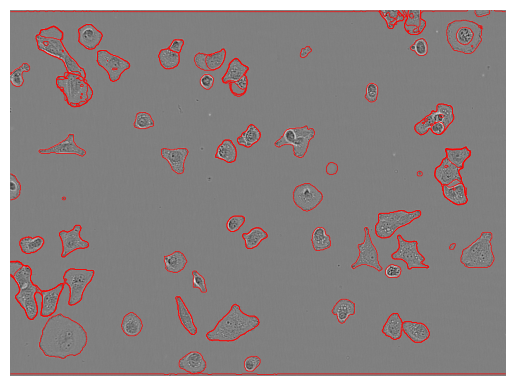

In [15]:
# Testing SAM on one of my images
import os
import cv2
import matplotlib.pyplot as plt
from src.crop_cells import segment_image

file_name = "A172_Phase_A7_1_00d04h00m_2.tif"
path = "/content/livecell/images/images/livecell_train_val_images"
segment_image(mask_generator=mask_generator, image_path=path, file_name=file_name)

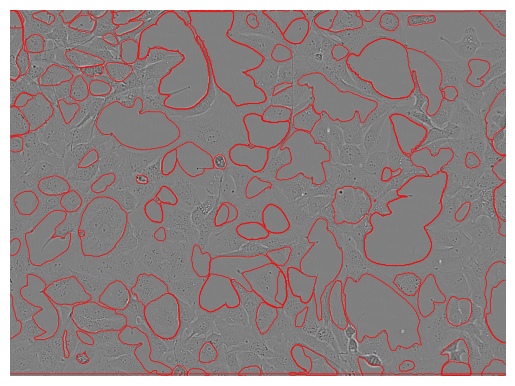

In [16]:
# Testing SAM on a challenging image

file_name = "A172_Phase_A7_1_02d00h00m_4.tif"
segment_image(mask_generator=mask_generator, image_path=path, file_name=file_name)




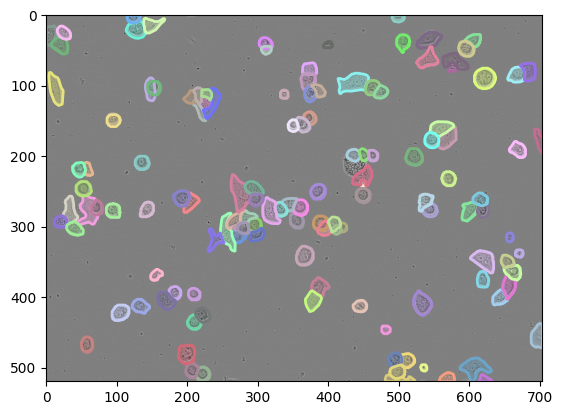

In [17]:
# Visualize Ground Truth Masks
ann_ids = coco.getAnnIds(imgIds=img_info['id'])
anns = coco.loadAnns(ann_ids)

image = cv2.imread(f"/content/livecell/images/images/livecell_train_val_images/{img_info['file_name']}")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
coco.showAnns(anns)
plt.show()

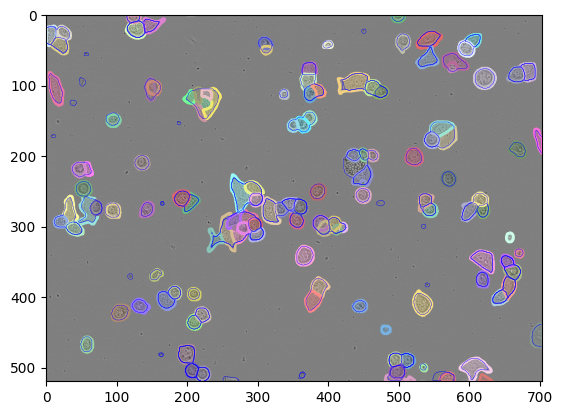

In [18]:
# Compare SAM vs. Ground truth
sam_masks = mask_generator.generate(image)

# visualize overlap
plt.imshow(image)
for m in sam_masks:
    plt.contour(m['segmentation'], colors='blue', linewidths=0.3)

coco.showAnns(anns)
plt.show()

--2026-04-26 23:46:11--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.35.238.84, 13.35.238.113, 13.35.238.71, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.35.238.84|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M  45.7MB/s    in 5.6s    

2026-04-26 23:46:16 (63.6 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



In [20]:
# Fine-tuning SAM
# Only the mask decoder will be fine tuned. The text and image encoder will not be fine-tuned:

import torch
from segment_anything import sam_model_registry

device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to(device)

# Freeze everything except mask decoder
for param in sam.image_encoder.parameters():
    param.requires_grad = False

for param in sam.prompt_encoder.parameters():
    param.requires_grad = False

In [21]:
# Optimizer
optimizer = torch.optim.SGD(
    sam.mask_decoder.parameters(),
    lr=1e-4
)

In [22]:
# Preparing Training Data
# Converting COCO Masks to bounding box
import numpy as np

def mask_to_box(mask):
    ys, xs = np.where(mask > 0)
    return np.array([xs.min(), ys.min(), xs.max(), ys.max()])

In [23]:
# Creating a Cell dataset class
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset

class LiveCellDataset(Dataset):
    def __init__(self, coco, img_ids, img_root):
        self.coco = coco
        self.img_ids = img_ids
        self.img_root = img_root

        # build list of (img_id, ann_id)
        self.samples = []
        for img_id in img_ids:
            ann_ids = coco.getAnnIds(imgIds=img_id)
            for ann_id in ann_ids:
                self.samples.append((img_id, ann_id))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_id, ann_id = self.samples[idx]

        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_root, img_info['file_name'])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ann = self.coco.loadAnns([ann_id])[0]
        mask = self.coco.annToMask(ann)

        # bounding box from mask
        ys, xs = np.where(mask > 0)
        box = np.array([xs.min(), ys.min(), xs.max(), ys.max()])

        return image, mask, box

In [24]:
# Creating a training and validation datasets
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
import random



img_ids = coco.getImgIds()
indices = random.sample(range(len(img_ids)), 3000)
img_ids = Subset(img_ids, indices)

train_ids, val_ids = train_test_split(img_ids, test_size=0.3, random_state=42)

In [25]:
# Create Datasets:
train_dataset = LiveCellDataset(coco, train_ids, "/content/livecell/images/images/livecell_train_val_images")
val_dataset   = LiveCellDataset(coco, val_ids, "/content/livecell/images/images/livecell_train_val_images")
print(len(train_dataset))
print(len(val_dataset))

655656
287221


In [26]:
# Selecting a smaller set to train:
from torch.utils.data import Subset
import random

indices = random.sample(range(len(train_dataset)), 10000)
train_dataset = Subset(train_dataset, indices)
val_indices = random.sample(range(len(val_dataset)), 3000)
val_dataset = Subset(val_dataset, val_indices)
#test_indices = random.sample(range(len(test_dataset)), 300)
#test_dataset = Subset(test_dataset, test_indices)

In [27]:
# Custom Collect function
def collate_fn(batch):
    images, masks, boxes = zip(*batch)
    return list(images), list(masks), list(boxes)

In [28]:
from itertools import accumulate
# DataLoaders
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=2,   # keep small (SAM is heavy)
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)

In [29]:
# Training Loop with DataLoaders
import torch.nn.functional as F
from segment_anything.utils.transforms import ResizeLongestSide
from src.train import *

transform = ResizeLongestSide(sam.image_encoder.img_size)

loss_fn = torch.nn.BCEWithLogitsLoss()


In [30]:

train_dir = "/content/livecell/images/images/livecell_train_val_images"
coco = COCO("/content/livecell/annotations/livecell_coco_train.json")

embedding_cache = embeddings_cashing(coco, train_dir, train_ids)

loading annotations into memory...
Done (t=17.53s)
creating index...
index created!


TypeError: embeddings_cashing() takes 2 positional arguments but 3 were given

In [ ]:
from src.train import save_checkpoint
from google.colab import files
import torch

# Training
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to(device)


# Freeze everything except mask decoder
for param in sam.image_encoder.parameters():
    param.requires_grad = False

for param in sam.prompt_encoder.parameters():
    param.requires_grad = False

optimizer = torch.optim.SGD(
    sam.mask_decoder.parameters(),
    lr=1e-4
)

training_losses = []
validation_losses = []
for epoch in range(30):
    train_loss = train_one_epoch_sam(embedding_cache, train_loader)
    training_losses.append(train_loss)
    val_loss = validate_sam(embedding_cache, val_loader)
    validation_losses.append(val_loss)
    save_checkpoint(sam, optimizer, epoch, f"/content/models/sam_100000_checkpoint.pth")

    print(f"Epoch {epoch+1}: Train {train_loss:.4f}, Val {val_loss:.4f}")

files.download("/content/models/sam_100000_checkpoint.pth")

In [ ]:
print(training_losses)
print(validation_losses)

In [ ]:
# Run but DO NOT MODIFY this code

from matplotlib import pyplot as plt

# Helper function to visualize performance during training
def plot_training_curves(train_losses, val_accuracies):


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(train_losses)
    ax1.set_title('Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True)

    ax2.plot(val_accuracies)
    ax2.set_title('Validation Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
plot_training_curves(training_losses, validation_losses)

In [ ]:
# Testing SAM on a challenging image
from google.colab import files
from segment_anything import SamAutomaticMaskGenerator
sam.eval()
uploaded = files.upload()
file_name = "A172_Phase_A7_1_02d00h00m_4.tif"
image = cv2.imread(f"{file_name}")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask_generator = SamAutomaticMaskGenerator(
    sam,
    pred_iou_thresh=0.6,
    stability_score_thresh=0.8,
    min_mask_region_area=0
)

masks = mask_generator.generate(image)

print(f"Number of masks: {len(masks)}")

plt.imshow(image)
for m in masks:
    plt.contour(m['segmentation'], colors='r', linewidths=0.5)
plt.show()